# Problem 2: German Credit Dataset
Given a CSV data file GermanCredit.csv (1000 records), load it into a Pandas DataFrame and perform preprocessing and analysis tasks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('GermanCredit.csv')
print('Shape:', df.shape)
df.head()

Shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,'<0',6,'critical/other existing credit',radio/tv,1169,'no known savings','>=7',4,'male single',none,...,'real estate',67,none,own,2,skilled,1,yes,yes,good
1,'0<=X<200',48,'existing paid',radio/tv,5951,'<100','1<=X<4',2,'female div/dep/mar',none,...,'real estate',22,none,own,1,skilled,1,none,yes,bad
2,'no checking',12,'critical/other existing credit',education,2096,'<100','4<=X<7',2,'male single',none,...,'real estate',49,none,own,1,'unskilled resident',2,none,yes,good
3,'<0',42,'existing paid',furniture/equipment,7882,'<100','4<=X<7',2,'male single',guarantor,...,'life insurance',45,none,'for free',1,skilled,2,none,yes,good
4,'<0',24,'delayed previously','new car',4870,'<100','1<=X<4',3,'male single',none,...,'no known property',53,none,'for free',2,skilled,2,none,yes,bad


## Preprocessing

### Task 1 [8 pts]: Drop the 3 columns that contribute the least to the dataset. These would be the columns with the highest number of non-zero 'none' values. Break ties by going left to right in columns. (Your code should be generalizable to drop n columns, but for the rest of the analysis, you can call your code for n=3.)

In [2]:
def drop_n_none_columns(dataframe, n=3):
    none_counts = {}
    for col in dataframe.columns:
        try:
            count = (dataframe[col].str.strip().str.lower() == 'none').sum()
        except AttributeError:
            count = 0
        none_counts[col] = count

    counts = pd.Series(none_counts)
    ordered_counts = counts.sort_values(ascending=False, kind='stable')
    drop_list = ordered_counts.head(n).index.tolist()

    print(f"None counts per column:\n{counts[counts > 0]}")
    print(f"\nDropping {n} columns: {drop_list}")
    return dataframe.drop(columns=drop_list)

df = drop_n_none_columns(df, n=3)
print(f"\nRemaining columns ({len(df.columns)}): {df.columns.tolist()}")

None counts per column:
other_parties          907
other_payment_plans    814
own_telephone          596
dtype: int64

Dropping 3 columns: ['other_parties', 'other_payment_plans', 'own_telephone']

Remaining columns (18): ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'residence_since', 'property_magnitude', 'age', 'housing', 'existing_credits', 'job', 'num_dependents', 'foreign_worker', 'class']


### Task 2 [4 pts]: Certain values in some of the columns contain unnecessary apostrophes ('). Remove the apostrophes.

In [3]:
for col in df.columns:
    try:
        df[col] = df[col].str.replace("'", "", regex=False)
    except AttributeError:
        pass  # skip non-string columns

print("Apostrophes removed. Sample values:")
print(df[['checking_status', 'savings_status', 'employment', 'job']].head(3))

Apostrophes removed. Sample values:
  checking_status    savings_status employment                 job
0              <0  no known savings        >=7             skilled
1        0<=X<200              <100     1<=X<4             skilled
2     no checking              <100     4<=X<7  unskilled resident


### Task 3 [5 pts]: The checking_status column has values in 4 categories: 'no checking', '<0', '0<=X<200', and '>=200'. Change these to 'No Checking', 'Low', 'Medium', and 'High' respectively.

In [4]:
checking_map = {
    'no checking': 'No Checking',
    '<0':          'Low',
    '0<=X<200':    'Medium',
    '>=200':       'High'
}
df['checking_status'] = df['checking_status'].str.strip().map(checking_map)
print("checking_status value counts:")
print(df['checking_status'].value_counts())

checking_status value counts:
checking_status
No Checking    394
Low            274
Medium         269
High            63
Name: count, dtype: int64


### Task 4 [5 pts]: The savings_status column has values in 4 categories: 'no known savings', '<100', '100<=X<500', '500<=X<1000', and '>=1000'. Change these to 'No Savings', 'Low', 'Medium', 'High', and 'High' respectively. (Yes, the last two are both 'High').

In [5]:
savings_map = {
    'no known savings': 'No Savings',
    '<100':             'Low',
    '100<=X<500':       'Medium',
    '500<=X<1000':      'High',
    '>=1000':           'High'
}
df['savings_status'] = df['savings_status'].str.strip().map(savings_map)
print("savings_status value counts:")
print(df['savings_status'].value_counts())

savings_status value counts:
savings_status
Low           603
No Savings    183
High          111
Medium        103
Name: count, dtype: int64


### Task 5 [3 pts]: Change class column values from 'good' to '1' and 'bad' to '0'.

In [6]:
df['class'] = df['class'].str.strip().map({'good': '1', 'bad': '0'})
print("class value counts:")
print(df['class'].value_counts())

class value counts:
class
1    700
0    300
Name: count, dtype: int64


### Task 6 [4 pts]: Change the employment column value 'unemployed' to 'Unemployed', and for the others, change to 'Amateur', 'Professional', 'Experienced' and 'Expert', depending on year range.

In [7]:
employment_map = {
    'unemployed': 'Unemployed',
    '<1':         'Amateur',
    '1<=X<4':     'Professional',
    '4<=X<7':     'Experienced',
    '>=7':        'Expert'
}
df['employment'] = df['employment'].str.strip().map(employment_map)
print("employment value counts:")
print(df['employment'].value_counts())

employment value counts:
employment
Professional    339
Expert          253
Experienced     174
Amateur         172
Unemployed       62
Name: count, dtype: int64


## Analysis

### Task 7 [3 pts]: Get the count of each category of foreign workers (yes and no) for each class of credit (good and bad).

In [8]:
foreignC = pd.crosstab(df['foreign_worker'], df['class'])
foreignC.columns.name = 'class (0=bad, 1=good)'
print(foreignC)

class (0=bad, 1=good)    0    1
foreign_worker                 
no                       4   33
yes                    296  667


### Task 8 [2 pts]: Similarly, get the count of each category of employment for each category of saving_status.

In [9]:
savingsE = pd.crosstab(df['employment'], df['savings_status'])
print(savingsE)

savings_status  High  Low  Medium  No Savings
employment                                   
Amateur           12  120      17          23
Experienced       18  100      24          32
Expert            34  133      22          64
Professional      44  210      33          52
Unemployed         3   40       7          12


### Task 9 [4 pts]: Find the average credit_amount of single males that have 4<=X<7 years of employment.

In [10]:
mask = (
    (df['personal_status'].str.strip() == 'male single') &
    (df['employment'] == 'Experienced')
)
avg_credit = df.loc[mask, 'credit_amount'].mean()
print(f"Average credit amount for single males with Experienced employment: {avg_credit}")

Average credit amount for single males with Experienced employment: 4142.592592592592


### Task 10 [4 pts]: Find the average credit duration for each of the job types.

In [11]:
avg_duration_by_job = df.groupby('job')['duration'].mean()
print("Average credit duration by job type:")
print(avg_duration_by_job)

Average credit duration by job type:
job
high qualif/self emp/mgmt    25.168919
skilled                      21.411111
unemp/unskilled non res      17.363636
unskilled resident           16.535000
Name: duration, dtype: float64


### Task 11 [4 pts]: For the purpose 'education', what is the most common checking_status and savings_status?

In [12]:
edu_df = df[df['purpose'].str.strip() == 'education']
most_common_checking = edu_df['checking_status'].mode()[0]
most_common_savings  = edu_df['savings_status'].mode()[0]
print(f"Most common checking status: {most_common_checking}")
print(f"Most common savings status: {most_common_savings}")

Most common checking status: No Checking
Most common savings status: Low


## Visualization

### Task 12 [9 pts]: Plot subplots of two bar charts: one for savings_status (x-axis) to personal status (y-axis), and another for checking_status (x-axis) to personal_status (y-axis). In each of the charts, each personal status category bar (number of people in that category) should be of a different color.

In [ ]:
#Please run the file for the graph to appear
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.tab10.colors

for ax, x_col, title in zip(
    axes,
    ['savings_status', 'checking_status'],
    ['Savings Status vs Personal Status', 'Checking Status vs Personal Status']
):
    crosstab = pd.crosstab(df[x_col], df['personal_status'])
    bottom = np.zeros(len(crosstab))
    for i, ps in enumerate(crosstab.columns):
        ax.bar(crosstab.index, crosstab[ps], bottom=bottom,
               label=ps, color=colors[i % len(colors)])
        bottom += crosstab[ps].values
    ax.set_xlabel(x_col.replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel('Number of People', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(title='Personal Status', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Personal Status Distribution by Account Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Task 13 [9 pts]: For people having credit_amount more than 4000, plot a bar graph which maps property_magnitude (x-axis) to the average customer age for that magnitude (y-axis).

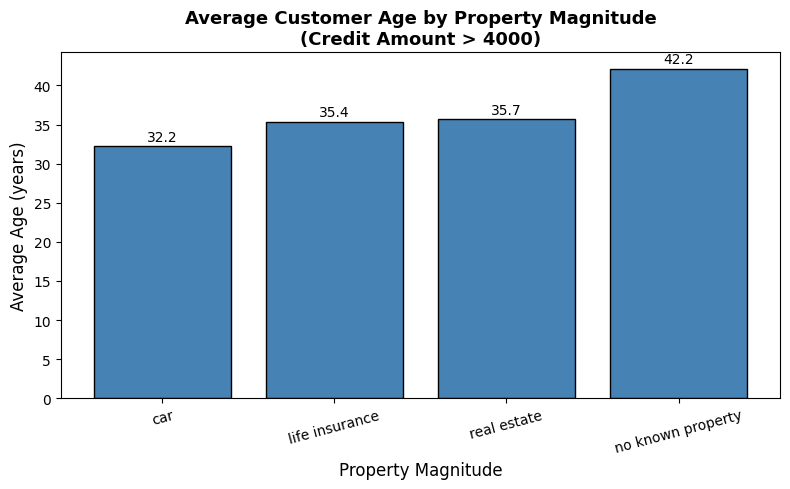

In [14]:
high_credit = df[df['credit_amount'] > 4000]
avg_age_by_property = high_credit.groupby('property_magnitude')['age'].mean().sort_values()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    avg_age_by_property.index,
    avg_age_by_property.values,
    color='steelblue',
    edgecolor='black'
)
plt.xlabel('Property Magnitude', fontsize=12)
plt.ylabel('Average Age (years)', fontsize=12)
plt.title('Average Customer Age by Property Magnitude\n(Credit Amount > 4000)', fontsize=13, fontweight='bold')
plt.xticks(rotation=15)

for bar, val in zip(bars, avg_age_by_property.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Task 14 [6 pts]: For people with a "High" savings_status and age above 40, use subplots to plot the following pie charts: Personal status, Credit history, Job

In [ ]:
#Please run the file for the graph to appear
subset = df[(df['savings_status'] == 'High') & (df['age'] > 40)]

pie_cols  = ['personal_status', 'credit_history', 'job']
pie_titles = ['Personal Status', 'Credit History', 'Job']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title in zip(axes, pie_cols, pie_titles):
    counts = subset[col].value_counts()
    ax.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.Set3.colors[:len(counts)]
    )
    ax.set_title(f'{title}\n(High Savings & Age > 40)', fontsize=12, fontweight='bold')

plt.suptitle('Distribution for High Savings Status Customers Aged Over 40',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()